In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

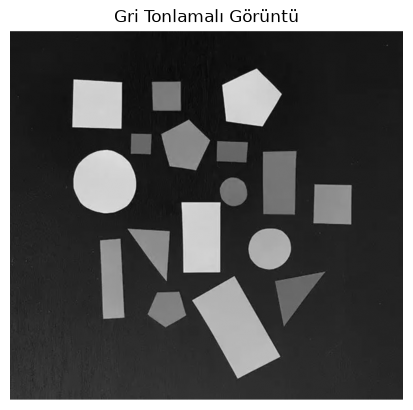

In [8]:
img=cv2.imread('sekiller.jpg')
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title('Gri Tonlamalı Görüntü')
plt.axis('off')
plt.show()


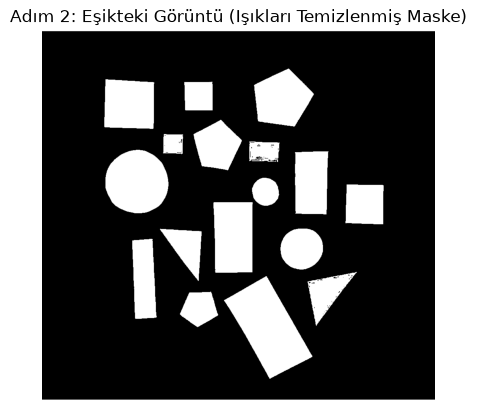

In [5]:
_, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
# Eşik değerini 100 yaparak resmin altındaki ışık yansımalarını eler, arka planı simsiyah (0), tüm 16 şekli net beyaz (255) yapar.

plt.imshow(thresh, cmap="gray")
# Temizlenmiş eşikteki görüntüyü gösterilmek üzere hazırlar.

plt.title("Adım 2: Eşikteki Görüntü (Işıkları Temizlenmiş Maske)")
plt.axis("off")
plt.show()



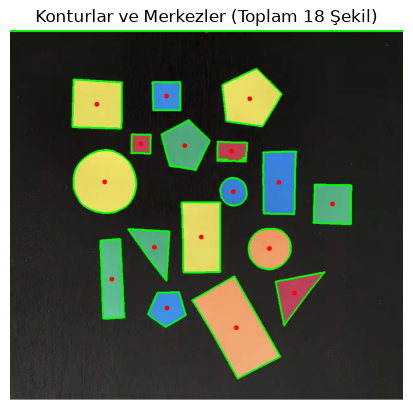

In [10]:
cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
output = img_rgb.copy()

valid_cnts = []
# Sadece gerçek nesneleri tutmak için boş liste oluşturur.

for cnt in cnts:
# Bulunan tüm konturlar üzerinde sırayla döngü başlatır.

    if cv2.contourArea(cnt) > 200:
    # Alanı 200 pikselden büyük olan gerçek şekilleri seçer (başlığın altındaki minik gürültü noktayı eler).

        valid_cnts.append(cnt)

        M = cv2.moments(cnt)
        # Gerçek şeklin momentlerini hesaplar.

        if M["m00"] != 0:
        # Ağırlık merkezini hesaplar.

            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            cv2.circle(output, (cX, cY), 6, (255, 0, 0), -1)
            # Sadece gerçek şekillerin tam merkezine kırmızı nokta koyar.

cv2.drawContours(output, valid_cnts, -1, (0, 255, 0), 3)
# Sadece filtrelenmiş gerçek şekillerin etrafına yeşil kontur çizer.

plt.imshow(output)
plt.title(f"Konturlar ve Merkezler (Toplam {len(valid_cnts)} Şekil)")
plt.axis("off")
plt.show()

